In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from spectral.io import envi
from spectral.io.envi import read_envi_header, write_envi_header
from glob import glob
import rasterio
from rasterio.windows import from_bounds, Window
from shapely.geometry import box
from scipy.ndimage import gaussian_filter
from isofit.utils import skyview

import sys
sys.path.append('/store/carroll/repos/neon-isofit/')
from utilities import *

os.environ["GDAL_PAM_ENABLED"] = "NO"

In [2]:
home = '/store/carroll/col/data/2018/'
data = os.path.join(home, 'raw/rmbl/')
flight = 'NIS01_20180612_155442'

r1 ='336000_4310000'
r2 ='336000_4307000'

rs = [r1, r2]

out = os.path.join(home, 'test_6c', 'subsets')
os.makedirs(out, exist_ok=True)

In [ ]:
# generate aligned subsets of rdn, obs, loc, and L3 lidar data

In [27]:
suffixes = [
    'rdn_ort', # rdn
    'rdn_obs_ort', # obs
    'rdn_ort_igm_ort', # loc
]
fps = [x for x in glob(data+f'*/{flight}*') if x.endswith(tuple(suffixes))]
fps

['/store/carroll/col/data/2018/raw/rmbl/2018061214/NIS01_20180612_155442_rdn_obs_ort',
 '/store/carroll/col/data/2018/raw/rmbl/2018061214/NIS01_20180612_155442_rdn_ort',
 '/store/carroll/col/data/2018/raw/rmbl/2018061214/NIS01_20180612_155442_rdn_ort_igm_ort']

In [28]:
# subset existing rdn, obs, loc files to the two NEON L3 lidar regions

for r_ in [r1, r2]:
    fp_r = glob(home+f'raw/L3/discreteLidar/CHM/*{r_}*.tif')[0]
    for fp in fps:
        with rasterio.open(fp) as src, rasterio.open(fp_r) as r:
            subset_bounds = box(*src.bounds).intersection(box(*r.bounds)) # get intersection of bounds
            window = rasterio.windows.from_bounds(*subset_bounds.bounds, transform=src.transform)
            subset = src.read(window=window)
            
            # copy envi hdr data
            tags = src.tags(ns='ENVI').copy()
            for k in ['samples', 'lines', 'bands']:
                tags.pop(k, None)
                
            profile = src.profile.copy()
            profile.update({
                'height': subset.shape[1],
                'width': subset.shape[2],
                'transform': rasterio.windows.transform(window, src.transform),
                'interleave': tags['interleave']})
            
            fp_out = os.path.join(out, f'{fp.split('/')[-1]}_{r_}')
            with rasterio.open(fp_out, 'w', **profile) as dst:
                dst.write(subset)
                dst.update_tags(ns='ENVI', **tags)
                try:
                    bn = tags['band_names']
                    bn = [s.strip() for s in bn[1:-1].split(',')]
                    for i, desc in enumerate(bn[:src.count], start=1):
                        dst.set_band_description(i, desc)
                except: pass

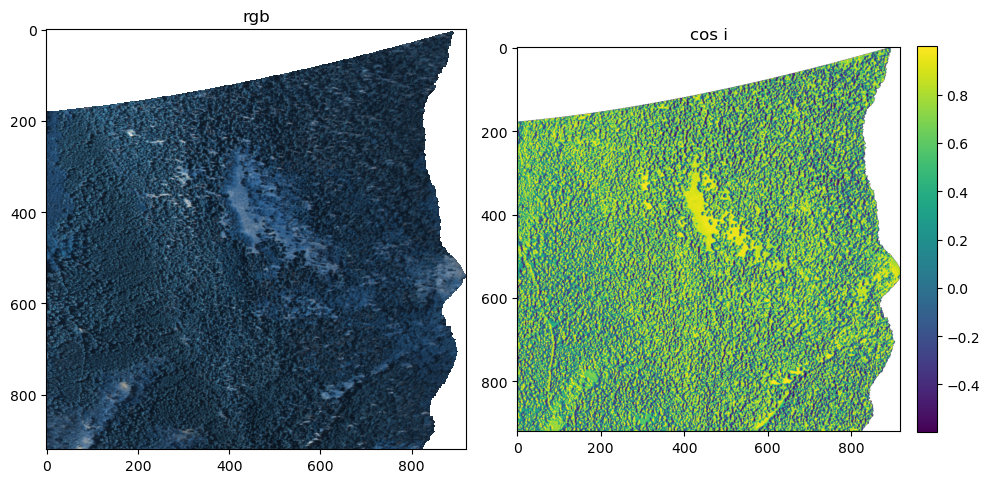

In [29]:
# figs, plots for Phil

# r1
fp_r1 = glob(out+f'/*obs*{r1}.hdr')[0]
r1_obs = envi.open(fp_r1).open_memmap()[...,8].copy() # cos i
r1_obs[r1_obs==-9999] = np.nan

fp_r1 = glob(out+f'/*rdn_ort_{r1}.hdr')[0]
r1_rdn = envi.open(fp_r1).open_memmap()[...,[60,40,30]].copy() # rgb
r1_rdn[r1_rdn==-9999] = np.nan

fig, axs = plt.subplots(ncols=2, figsize=(10,5))

axs[0].imshow(r1_rdn / np.nanmax(r1_rdn, axis=(0, 1)))
axs[0].set_title('rgb')

im = axs[1].imshow(r1_obs)
axs[1].set_title('cos i')

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

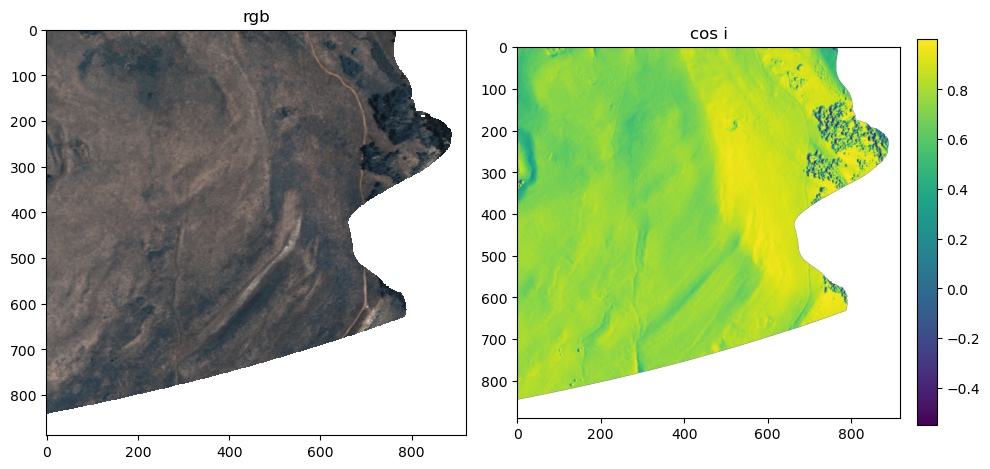

In [30]:
# r2
fp_r1 = glob(out+f'/*obs*{r2}.hdr')[0]
r1_obs = envi.open(fp_r1).open_memmap()[...,8].copy() # cos i
r1_obs[r1_obs==-9999] = np.nan

fp_r1 = glob(out+f'/*rdn_ort_{r2}.hdr')[0]
r1_rdn = envi.open(fp_r1).open_memmap()[...,[60,40,30]].copy() # rgb
r1_rdn[r1_rdn==-9999] = np.nan

fig, axs = plt.subplots(ncols=2, figsize=(10,5))

axs[0].imshow(r1_rdn / np.nanmax(r1_rdn, axis=(0, 1)))
axs[0].set_title('rgb')

im = axs[1].imshow(r1_obs)
axs[1].set_title('cos i')

fig.colorbar(im, ax=axs[1], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

In [24]:
# subset L3 lidar data to the two subset regions

for r_ in [r1, r2]:
    fp_r = glob(out+f'/*rdn*{r_}')[0]
    fps = glob(home+f'raw/L3/discreteLidar/*/*{r_}*.tif')
    for fp in fps:
        print(fp)
        with rasterio.open(fp) as src, rasterio.open(fp_r) as r:
            subset_bounds = box(*src.bounds).intersection(box(*r.bounds)) # get intersection of bounds
            window = rasterio.windows.from_bounds(*subset_bounds.bounds, transform=src.transform)
            subset = src.read(window=window)
                
            profile = src.profile.copy()
            profile.update({
                'height': subset.shape[1],
                'width': subset.shape[2],
                'transform': rasterio.windows.transform(window, src.transform)})
            
            fp_out = os.path.join(out, f'{fp.split('/')[-1]}')
            with rasterio.open(fp_out, 'w', **profile) as dst:
                dst.write(subset)

/store/carroll/col/data/2018/raw/L3/discreteLidar/CHM/NEON_D13_CRBU_DP3_336000_4310000_CHM.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/DSM/NEON_D13_CRBU_DP3_336000_4310000_DSM.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/DTM/NEON_D13_CRBU_DP3_336000_4310000_DTM.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/slope/NEON_D13_CRBU_DP3_336000_4310000_slope.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/CHM/NEON_D13_CRBU_DP3_336000_4307000_CHM.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/DSM/NEON_D13_CRBU_DP3_336000_4307000_DSM.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/DTM/NEON_D13_CRBU_DP3_336000_4307000_DTM.tif
/store/carroll/col/data/2018/raw/L3/discreteLidar/slope/NEON_D13_CRBU_DP3_336000_4307000_slope.tif


In [22]:
# generate custom surface representations

for i in range(3, 10, 2):
    smooth_out_folder = os.path.join(out, f'smooth{i}')
    os.makedirs(smooth_out_folder, exist_ok=True)
    for r in [r1, r2]:
        # load subset data
        chm = rasterio.open(glob(os.path.join(out, f'*{r}_CHM.tif'))[0]).read(1)
        dtm = rasterio.open(glob(os.path.join(out, f'*{r}_DTM.tif'))[0]).read(1)
        obs = envi.open(glob(os.path.join(out, f'*obs*{r}.hdr'))[0]).open_memmap().copy()
        loc = envi.open(glob(os.path.join(out, f'*igm*{r}.hdr'))[0]).open_memmap().copy()

        # calculate smoothed dsm, slope, aspect
        chm_smooth = gaussian_filter(chm, sigma=i)
        dsm_smooth = chm_smooth + dtm
        slope, aspect = skyview.gradient_d8(dsm_smooth, dx=1, dy=1, aspect_rad=True) # slope, aspect in rad

        # calculate cos i
        obs[obs==-9999] = np.nan
        solar_az = np.radians(obs[...,3])
        solar_zen = np.radians(obs[...,4])
        cos_i = (np.cos(solar_zen) * np.cos(slope) + np.sin(solar_zen) * np.sin(slope) * np.cos(solar_az - aspect)) 

        # standardize NAs across surface
        cos_i[np.isnan(cos_i)] = -9999
        slope[cos_i==-9999] = -9999
        aspect[cos_i==-9999] = -9999
        dsm_smooth[cos_i==-9999] = -9999   

        # update obs, loc files
        loc[...,2] = dsm_smooth
        obs[...,6] = np.degrees(slope)
        obs[...,7] = np.degrees(aspect)
        obs[...,8] = cos_i

        # standardize NAs across datasets
        rdn = envi.open(glob(os.path.join(out, f'*rdn_ort_{r}.hdr'))[0]).open_memmap().copy()
        na_mask = np.any(obs==-9999, axis=2) | np.any(loc==-9999, axis=2) | np.any(rdn==-9999, axis=2)
        rdn[na_mask, :] = -9999
        obs[na_mask, :] = -9999
        loc[na_mask, :] = -9999

        # export

        # rdn
        fp_rdn = glob(os.path.join(out, f'*rdn_ort_{r}.hdr'))[0]
        hdr = envi.read_envi_header(fp_rdn).copy()
        fp_out = os.path.join(smooth_out_folder, fp_rdn.split('/')[-1])
        envi.save_image(fp_out, rdn, interleave=hdr['interleave'], metadata=hdr, force=True)
        
        # obs
        hdr = envi.read_envi_header(glob(os.path.join(out, f'*obs*{r}.hdr'))[0]).copy()
        fp_out = os.path.join(smooth_out_folder, f'obs_{r}.hdr')
        envi.save_image(fp_out, obs, interleave=hdr['interleave'], metadata=hdr, force=True)
        
        # loc
        hdr = envi.read_envi_header(glob(os.path.join(out, f'*igm*{r}.hdr'))[0]).copy()
        fp_out = os.path.join(smooth_out_folder, f'loc_{r}.hdr')
        envi.save_image(fp_out, loc, interleave=hdr['interleave'], metadata=hdr, force=True)

In [16]:
# also just dtm

for r in [r1, r2]:
    # load subset data
    dtm = rasterio.open(glob(os.path.join(out, f'*{r}_DTM.tif'))[0]).read(1)
    obs = envi.open(glob(os.path.join(out, f'*obs*{r}.hdr'))[0]).open_memmap().copy()
    loc = envi.open(glob(os.path.join(out, f'*igm*{r}.hdr'))[0]).open_memmap().copy()
    obs[obs==-9999] = np.nan
    loc[loc==-9999] = np.nan
    dtm[np.isnan(obs[...,0])] = np.nan
    
    slope, aspect = skyview.gradient_d8(dtm, dx=1, dy=1, aspect_rad=True) # slope, aspect in rad

    # calculate cos i
    solar_az = np.radians(obs[...,3])
    solar_zen = np.radians(obs[...,4])
    cos_i = (np.cos(solar_zen) * np.cos(slope) + np.sin(solar_zen) * np.sin(slope) * np.cos(solar_az - aspect))        

    # turn NAs back to -9999
    dtm[np.isnan(dtm)] = -9999
    slope[np.isnan(slope)] = -9999
    aspect[np.isnan(aspect)] = -9999
    cos_i[np.isnan(cos_i)] = -9999

    # update obs, loc files
    loc[...,2] = dtm
    obs[...,6] = np.degrees(slope)
    obs[...,7] = np.degrees(aspect)
    obs[...,8] = cos_i
    obs[np.isnan(obs)] = -9999
    loc[np.isnan(loc)] = -9999

    # export
    # obs
    hdr = envi.read_envi_header(glob(os.path.join(out, f'*obs*{r}.hdr'))[0]).copy()
    fp_out = os.path.join(out, 'dtm', f'obs_{r}.hdr')
    envi.save_image(fp_out, obs, interleave=hdr['interleave'], metadata=hdr, force=True)
    # loc
    hdr = envi.read_envi_header(glob(os.path.join(out, f'*igm*{r}.hdr'))[0]).copy()
    fp_out = os.path.join(out, 'dtm', f'loc_{r}.hdr')
    envi.save_image(fp_out, loc, interleave=hdr['interleave'], metadata=hdr, force=True)